# ***Mount Google Drive***

In [5]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ***IMPORTS***

In [6]:
# Core
import os
import numpy as np

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input

# Sklearn
from sklearn.utils.class_weight import compute_class_weight

# ***Paths (EDIT THESE ONLY)***

In [10]:
# Folder structure on Drive:
#   Train/  → 9650 images  → used fully for training
#   Test/   → 2180 images  → split 50/50 → Val (1090) + Test (1090)

TRAIN_DIR = "/content/drive/MyDrive/Dataset/CLASSIFICATION_Epic and CSCR hospital Dataset_clean/Train"
#G:\My Drive\                       Dataset\
TEST_DIR  = "/content/drive/MyDrive/Dataset/CLASSIFICATION_Epic and CSCR hospital Dataset_clean/Test"

MODEL_SAVE_PATH = "/content/drive/MyDrive/models/densenet201.keras"

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test  exists:", os.path.exists(TEST_DIR))
print("Model save path:", os.path.exists("/content/drive/MyDrive/models"))

Train exists: True
Test  exists: True
Model save path: True


# ***Config***

In [11]:
IMG_SIZE   = 224
BATCH_SIZE = 16
SEED       = 42

HEAD_EPOCHS = 8
FT1_EPOCHS  = 8
FT2_EPOCHS  = 6

TARGET_ACC  = 0.95
GRAPHS      = []

# ***===============================***
# ***DATA LOADING***
# ***===============================***

# ***LOAD TRAIN***

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes    :", class_names)
print("Num Classes:", NUM_CLASSES)

Found 9650 files belonging to 4 classes.
Classes    : ['glioma', 'meningioma', 'notumor', 'pituitary']
Num Classes: 4


# ***SPLIT TEST FOLDER → VAL (50%) + TEST (50%)***

In [13]:
# Test folder has 2180 images — split 50/50
# First half  → Validation (~1090)
# Second half → Test       (~1090)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    validation_split=0.5,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    validation_split=0.5,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

print("Split complete:")
print(f"  Val  batches : {val_ds.cardinality().numpy()}")
print(f"  Test batches : {test_ds.cardinality().numpy()}")

Found 2180 files belonging to 4 classes.
Using 1090 files for training.
Found 2180 files belonging to 4 classes.
Using 1090 files for validation.
Split complete:
  Val  batches : 69
  Test batches : 69


# ***PREFETCH***

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# ***AUGMENTATION***

In [15]:
# Applied only to train — val and test are never augmented
augment = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),

])

train_ds = train_ds.map(
    lambda x, y: (augment(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

# ***CLASS WEIGHTS***

In [16]:
# glioma(3018) >> notumor(1945) — weights fix this imbalance
labels = []

for _, y in train_ds:
    labels.extend(np.argmax(y.numpy(), axis=1))

labels = np.array(labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(weights))

print("Class Weights:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_weights[i]:.4f}")

Class Weights:
  glioma: 0.7994
  meningioma: 1.1051
  notumor: 1.2404
  pituitary: 0.9635


# ***CALLBACKS***

In [17]:
callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_temp.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        mode="max"
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.3,
        min_lr=1e-7
    )

]

# ***BUILD MODEL***

In [18]:
base_model = DenseNet201(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False


inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))

x = preprocess_input(inputs)

x = base_model(x, training=False)

# Dual pooling — richer features, reduces overfitting vs GAP alone
gap = tf.keras.layers.GlobalAveragePooling2D()(x)
gmp = tf.keras.layers.GlobalMaxPooling2D()(x)
x   = tf.keras.layers.Concatenate()([gap, gmp])

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 224, 224,  │          0 │ add[0][0]         │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet201         │ (None, 7, 7,      │ 18,321,984 │ true_divide_1[0]… │
│ (Functional)        │ 1920)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1920)      │          0 │ densenet201[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1920)      │          0 │ densenet201[0][0] │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3840)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 3840)      │     15,360 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    983,296 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │      1,028 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,321,668 (73.71 MB)

 Trainable params: 992,004 (3.78 MB)

 Non-trainable params: 18,329,664 (69.92 MB)

# ***LOSS & METRICS***

In [19]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

metrics = [
    "accuracy",
    tf.keras.metrics.Precision(),
    tf.keras.metrics.Recall()
]

# ***===============================***
# ***PHASE 1 — HEAD TRAINING (8)***
# ***===============================***

In [20]:
# Base fully frozen — only custom head trains
print("Phase 1 — Head Training...")

model.compile(
    optimizer=tf.keras.optimizers.AdamW(1e-3),
    loss=loss_fn,
    metrics=metrics
)

hist_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

model.load_weights("best_temp.h5")
GRAPHS.append(hist_head)

print(f"Phase 1 Best Val Acc: {max(hist_head.history['val_accuracy']):.4f}")

Phase 1 — Head Training...
Epoch 1/8
604/604 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7157 - loss: 1.0789 - precision: 0.7600 - recall: 0.6633

604/604 ━━━━━━━━━━━━━━━━━━━━ 176s 211ms/step - accuracy: 0.7732 - loss: 0.9206 - precision: 0.8230 - recall: 0.7074 - val_accuracy: 0.7587 - val_loss: 0.9207 - val_precision: 0.8038 - val_recall: 0.6991 - learning_rate: 0.0010
Epoch 2/8
603/604 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8205 - loss: 0.7899 - precision: 0.8670 - recall: 0.7547

604/604 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - accuracy: 0.8304 - loss: 0.7731 - precision: 0.8786 - recall: 0.7639 - val_accuracy: 0.7780 - val_loss: 0.8609 - val_precision: 0.8253 - val_recall: 0.7413 - learning_rate: 0.0010
Epoch 3/8
603/604 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8436 - loss: 0.7483 - precision: 0.8877 - recall: 0.7780

604/604 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.8454 - loss: 0.7418 - precision: 0.8970 - recall: 0.7851 - val_accuracy: 0.7945 - val_loss: 0.8535 - val_precision: 0.8278 - val_recall: 0.7587 - learning_rate: 0.0010
Epoch 4/8
602/604 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8550 - loss: 0.7298 - precision: 0.9029 - recall: 0.7920

604/604 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - accuracy: 0.8596 - loss: 0.7250 - precision: 0.9054 - recall: 0.8023 - val_accuracy: 0.8000 - val_loss: 0.8583 - val_precision: 0.8440 - val_recall: 0.7642 - learning_rate: 0.0010
Epoch 5/8
604/604 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.8635 - loss: 0.7201 - precision: 0.9033 - recall: 0.8035 - val_accuracy: 0.7991 - val_loss: 0.8460 - val_precision: 0.8511 - val_recall: 0.7550 - learning_rate: 0.0010
Epoch 6/8
602/604 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8626 - loss: 0.7281 - precision: 0.9051 - recall: 0.8071

604/604 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.8638 - loss: 0.7261 - precision: 0.9064 - recall: 0.8075 - val_accuracy: 0.8055 - val_loss: 0.8270 - val_precision: 0.8402 - val_recall: 0.7670 - learning_rate: 0.0010
Epoch 7/8
604/604 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.8719 - loss: 0.7192 - precision: 0.9109 - recall: 0.8153 - val_accuracy: 0.7798 - val_loss: 0.9233 - val_precision: 0.8201 - val_recall: 0.7404 - learning_rate: 0.0010
Epoch 8/8
604/604 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.8760 - loss: 0.7216 - precision: 0.9133 - recall: 0.8136 - val_accuracy: 0.8009 - val_loss: 0.8713 - val_precision: 0.8443 - val_recall: 0.7560 - learning_rate: 0.0010
Phase 1 Best Val Acc: 0.8055


# ***===============================***
# ***PHASE 2 — FINE-TUNE 50% (8)***
# ***===============================***

In [21]:
# Unfreeze top 50% of DenseNet layers
print("Phase 2 — Fine-Tune 50%...")

n        = len(base_model.layers)
unfreeze = int(0.5 * n)

for layer in base_model.layers[unfreeze:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.AdamW(2e-5),
    loss=loss_fn,
    metrics=metrics
)

hist_ft1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FT1_EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

model.load_weights("best_temp.h5")
GRAPHS.append(hist_ft1)

best_val = max(hist_ft1.history["val_accuracy"])
print(f"Phase 2 Best Val Acc: {best_val:.4f}")

Phase 2 — Fine-Tune 50%...
Epoch 1/8
604/604 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.8622 - loss: 0.7322 - precision: 0.8994 - recall: 0.7838

604/604 ━━━━━━━━━━━━━━━━━━━━ 621s 635ms/step - accuracy: 0.8892 - loss: 0.6894 - precision: 0.9214 - recall: 0.8209 - val_accuracy: 0.8495 - val_loss: 0.7457 - val_precision: 0.8739 - val_recall: 0.8266 - learning_rate: 2.0000e-05
Epoch 2/8
603/604 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9314 - loss: 0.6201 - precision: 0.9555 - recall: 0.8866

604/604 ━━━━━━━━━━━━━━━━━━━━ 46s 75ms/step - accuracy: 0.9344 - loss: 0.6138 - precision: 0.9569 - recall: 0.8937 - val_accuracy: 0.8917 - val_loss: 0.6475 - val_precision: 0.9172 - val_recall: 0.8633 - learning_rate: 2.0000e-05
Epoch 3/8
603/604 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9464 - loss: 0.5868 - precision: 0.9659 - recall: 0.9152

604/604 ━━━━━━━━━━━━━━━━━━━━ 46s 75ms/step - accuracy: 0.9517 - loss: 0.5772 - precision: 0.9692 - recall: 0.9223 - val_accuracy: 0.9165 - val_loss: 0.6206 - val_precision: 0.9376 - val_recall: 0.8954 - learning_rate: 2.0000e-05
Epoch 4/8
604/604 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.9596 - loss: 0.5595 - precision: 0.9727 - recall: 0.9344 - val_accuracy: 0.9138 - val_loss: 0.6157 - val_precision: 0.9366 - val_recall: 0.8945 - learning_rate: 2.0000e-05
Epoch 5/8
603/604 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9654 - loss: 0.5482 - precision: 0.9773 - recall: 0.9420

604/604 ━━━━━━━━━━━━━━━━━━━━ 46s 75ms/step - accuracy: 0.9677 - loss: 0.5431 - precision: 0.9788 - recall: 0.9470 - val_accuracy: 0.9220 - val_loss: 0.5961 - val_precision: 0.9438 - val_recall: 0.9083 - learning_rate: 2.0000e-05
Epoch 6/8
603/604 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9704 - loss: 0.5323 - precision: 0.9807 - recall: 0.9490

604/604 ━━━━━━━━━━━━━━━━━━━━ 47s 77ms/step - accuracy: 0.9712 - loss: 0.5319 - precision: 0.9816 - recall: 0.9492 - val_accuracy: 0.9376 - val_loss: 0.5748 - val_precision: 0.9422 - val_recall: 0.9266 - learning_rate: 2.0000e-05
Epoch 7/8
603/604 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9743 - loss: 0.5246 - precision: 0.9822 - recall: 0.9579

604/604 ━━━━━━━━━━━━━━━━━━━━ 46s 75ms/step - accuracy: 0.9750 - loss: 0.5218 - precision: 0.9839 - recall: 0.9591 - val_accuracy: 0.9468 - val_loss: 0.5706 - val_precision: 0.9584 - val_recall: 0.9303 - learning_rate: 2.0000e-05
Epoch 8/8
603/604 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9795 - loss: 0.5124 - precision: 0.9860 - recall: 0.9638

604/604 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.9794 - loss: 0.5132 - precision: 0.9863 - recall: 0.9644 - val_accuracy: 0.9615 - val_loss: 0.5402 - val_precision: 0.9675 - val_recall: 0.9550 - learning_rate: 2.0000e-05
Phase 2 Best Val Acc: 0.9615


# ***===============================***
# ***PHASE 3 — FULL FINE-TUNE (if val_acc < 95%)***
# ***===============================***

In [22]:
if best_val < TARGET_ACC:

    print(f"Val Acc {best_val:.4f} < {TARGET_ACC} — Running Full Fine-Tune...")

    base_model.trainable = True

    # Very low LR — DenseNet201 has 708 layers, aggressive LR will overfit
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(5e-6),
        loss=loss_fn,
        metrics=metrics
    )

    hist_ft2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FT2_EPOCHS,
        callbacks=callbacks,
        class_weight=class_weights
    )

    model.load_weights("best_temp.h5")
    GRAPHS.append(hist_ft2)

    print(f"Phase 3 Best Val Acc: {max(hist_ft2.history['val_accuracy']):.4f}")

else:

    print(f"Val Acc {best_val:.4f} >= {TARGET_ACC} — Skipping Phase 3 ✅")

Val Acc 0.9615 >= 0.95 — Skipping Phase 3 ✅


# ***===============================***
# ***GRAPH***
# ***===============================***

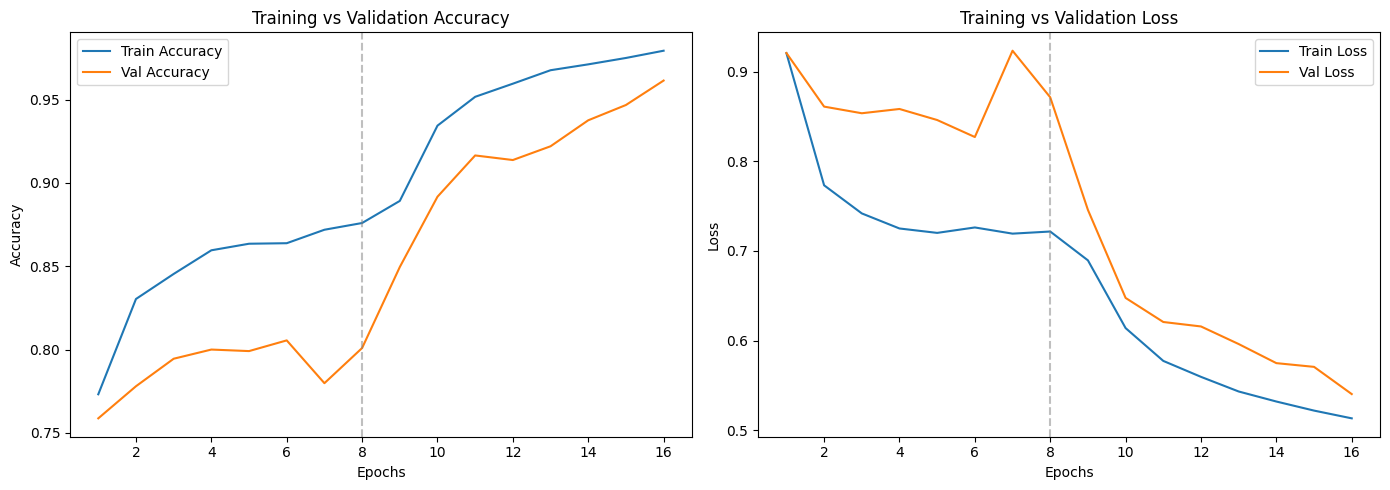

In [23]:
import matplotlib.pyplot as plt


def plot_history(histories):

    train_acc  = []
    val_acc    = []
    train_loss = []
    val_loss   = []

    for h in histories:
        train_acc  += h.history["accuracy"]
        val_acc    += h.history["val_accuracy"]
        train_loss += h.history["loss"]
        val_loss   += h.history["val_loss"]

    epochs = range(1, len(train_acc) + 1)

    # Phase boundary markers
    boundaries = []
    count = 0
    for h in histories[:-1]:
        count += len(h.history["accuracy"])
        boundaries.append(count)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, label="Train Accuracy")
    plt.plot(epochs, val_acc,   label="Val Accuracy")
    for b in boundaries:
        plt.axvline(x=b, color="gray", linestyle="--", alpha=0.5)
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss,   label="Val Loss")
    for b in boundaries:
        plt.axvline(x=b, color="gray", linestyle="--", alpha=0.5)
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_history(GRAPHS)

# ***===============================***
# ***CONFUSION MATRIX***
# ***===============================***

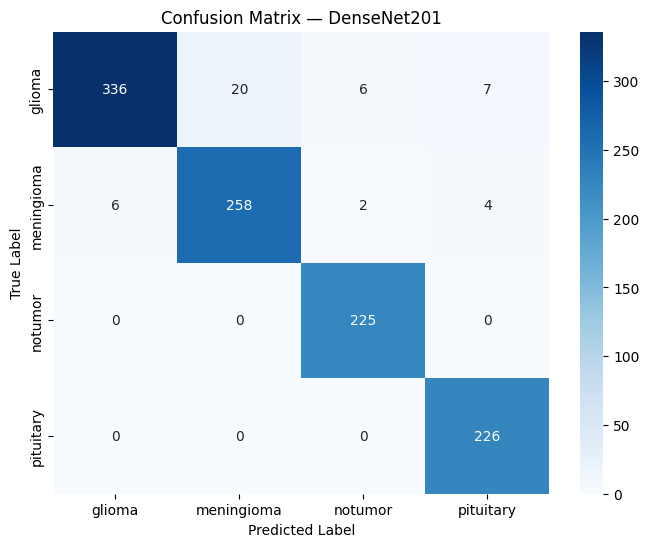

Classification Report:

              precision    recall  f1-score   support

      glioma       0.98      0.91      0.95       369
  meningioma       0.93      0.96      0.94       270
     notumor       0.97      1.00      0.98       225
   pituitary       0.95      1.00      0.98       226

    accuracy                           0.96      1090
   macro avg       0.96      0.97      0.96      1090
weighted avg       0.96      0.96      0.96      1090



In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for x, y in test_ds:

    preds = model.predict(x, verbose=0)

    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — DenseNet201")

plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# ***===============================***
# ***EVALUATE***
# ***===============================***

In [25]:
print("Evaluating on Test Set...")

model.evaluate(test_ds)

Evaluating on Test Set...
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9587 - loss: 0.5373 - precision: 0.9664 - recall: 0.9514


[0.5372516512870789,
 0.9587156176567078,
 0.9664492011070251,
 0.9513761401176453]

# ***===============================***
# ***SAVE MODEL***
# ***===============================***

In [26]:
model.save(MODEL_SAVE_PATH)

H5_PATH = MODEL_SAVE_PATH.replace(".keras", ".h5")
model.save(H5_PATH)

print("Model saved at:")
print("Keras :", MODEL_SAVE_PATH)
print("H5    :", H5_PATH)

Model saved at:
Keras : /content/drive/MyDrive/models/densenet201.keras
H5    : /content/drive/MyDrive/models/densenet201.h5
